In [1]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

In [2]:
from satellite_RFI.src.satellite_sims import satellite_sim as ss
import time
import pickle
import astropy.units as u
from datetime import datetime
import tqdm
import os


import scipy as sp
import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt

In [3]:
obs_time_input=None#'2021 9 30 20 06 36'
# fname = '1554156377'
fname = '1551055211'


"""
Establishing the file name
"""
if obs_time_input!=None:
    obs_time_in=[int(x) for x in obs_time_input.split()]
    obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
    dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
    fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
    print ("File name to be used is: "+str(fname))

else:
    print ("File name to be used is: "+str(fname))
    dt = (datetime.utcfromtimestamp(float(fname)).strftime('%Y-%m-%d %H:%M:%S'))
    print ("Date of observation date: "+str(dt))


##   
    
katdal_info = pickle.load(open('../../../Observation_results/Untangle/'+str(fname)+'/'+str(fname)+'_katdal_info.p', 'rb'), encoding='latin1')



info = [katdal_info[i] for i in katdal_info.keys()]

nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']
fs=1000
fe=1500

data_save='../../../Observation_results/Untangle/'+str(fname)+'/sat_sims/'
if os.path.exists(data_save)==False:
    os.mkdir(data_save)
    
data_mkat = '../../../Observation_results/Untangle/'+str(fname)+'/'

File name to be used is: 1551055211
Date of observation date: 2019-02-25 00:40:11


#### $\chi^2$ on alpha parameters

In [4]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Testing the ability to retrieve a simulated result

In [5]:
s_time = time.time()


sat = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1.csv',
            plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe], constellations=['GPS'])

print (time.time() - s_time)


Number of constellations:  1
Length of the satellite catalogue:  13
4.525852680206299


In [6]:
dic = {'Alpha':np.random.random(sat.alpha_len)*2}   # Parameter of ones based on the length of the satellite signals

In [7]:
dic

{'Alpha': array([1.1502815 , 0.4208096 , 1.7658847 , 0.05546067, 1.82131635,
        0.39127212, 0.40053913, 0.48095992, 0.26314936, 1.25808348,
        0.56729295, 0.02159574, 0.28210246])}

In [8]:
sat.excecute(a_param=dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1.5], add_sub=[1, 1], band_lvl=[None, None])




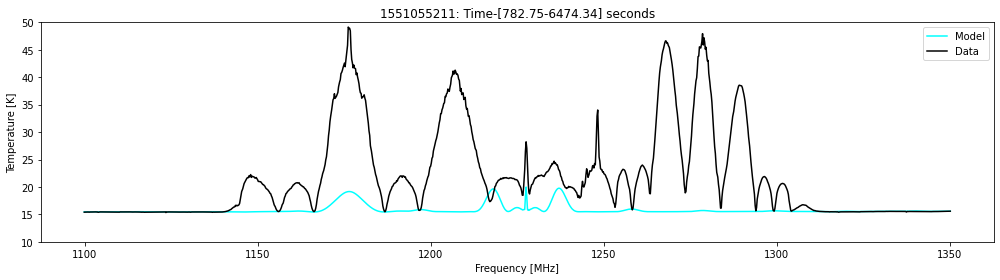

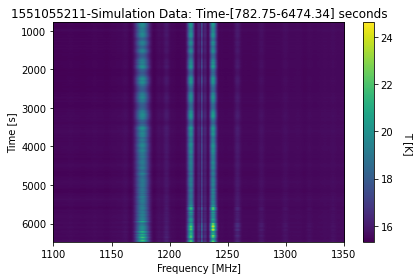

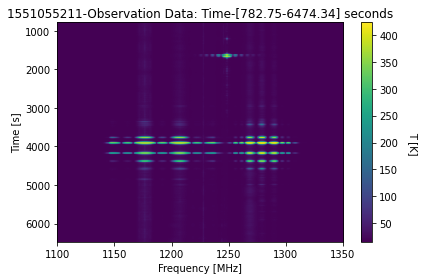

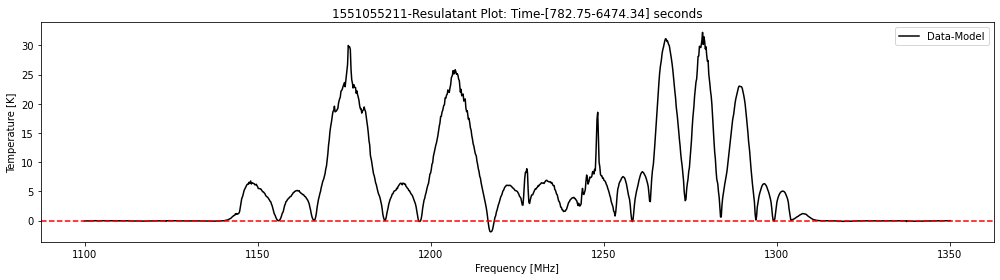

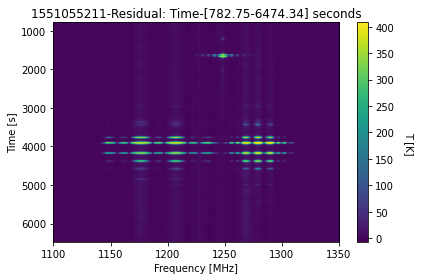

In [11]:
sat.plotting(individual=None, logger=1, axis_limit=[None, None, 10, 50], tod_limit=None, save_file=None, file_type='pdf')


In [12]:
# Pseudo data using for the test with only GPS 

pseudo_data = sat.simulation_TOD_slice

In [13]:
pseudo_data_noise = np.random.normal(pseudo_data, 10)


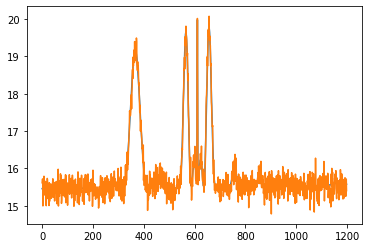

In [14]:
plt.plot(np.mean(pseudo_data, axis=1))
plt.plot(np.mean(pseudo_data_noise, axis=1))

In [15]:
sat2 =ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1.csv',
            plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe], constellations=['GPS'])


Number of constellations:  1
Length of the satellite catalogue:  13


In [16]:
dic2 = {'Alpha':np.ones(sat2.alpha_len)}   # Parameter of ones based on the length of the satellite signals

In [17]:
def chisq_func2(a_param):
    """
    Chi2 function which will take in all the parameters for the satellites
    """

    sat2.excecute(a_param, obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1.5], add_sub=[1, 1], band_lvl=[None, None])

    
    
    simulation = sat2.simulation_TOD_slice
    data = pseudo_data
    
    chi_sq = np.sum(((simulation) - (data))**2 / (data)**2)
    print (chi_sq)
    print (a_param)
    print ('\n')
    return chi_sq

In [18]:
chi2_res = chisq_func2(a_param=dic2['Alpha'])

85916.66703536788
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]




In [19]:
x = (0.00001, 2)
# bnds = [x for i in range(len(dic['Alpha']))]
bnds = [x for i in range(sat2.alpha_len)]

In [20]:
signal_PL = opt.minimize(fun=chisq_func2, 
                         x0=dic2['Alpha'], 
                         method='Powell',
                         bounds=bnds, 
                         tol=1e-6, 
                         options={'maxiter':20})

85916.66703536788
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


85916.48490082665
[0.7639382 1.        1.        1.        1.        1.        1.
 1.        1.        1.        1.        1.        1.       ]


85916.8492091419
[1.2360718 1.        1.        1.        1.        1.        1.
 1.        1.        1.        1.        1.        1.       ]


85916.25980893854
[0.47214359 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.        ]


85916.12071857767
[0.29180461 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.        ]


85916.03476520353
[0.18034899 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.        ]


85915.98164660952
[0.11146562 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.        ]


85915.9488188547
[0.06889336 1.         1.  

In [29]:
dic['Alpha']  - signal_PL.x

array([-4.59876581e-12,  7.89606991e-10, -5.54499513e-02,  5.54499502e-02,
        1.60872719e+00, -1.60872719e+00, -2.09193773e-12,  4.68260904e-01,
       -4.68260904e-01,  4.32707047e-01, -4.32707047e-01,  2.13684444e-02,
       -2.13684444e-02])

In [22]:
signal_PL.x

array([1.15028150e+00, 4.20809604e-01, 1.82133466e+00, 1.07218672e-05,
       2.12589162e-01, 1.99999931e+00, 4.00539127e-01, 1.26990120e-02,
       7.31410259e-01, 8.25376435e-01, 1.00000000e+00, 2.27293958e-04,
       3.03470901e-01])

In [23]:
sat3 =ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1.csv',
            plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe], constellations=['GPS'])


Number of constellations:  1
Length of the satellite catalogue:  13


In [24]:
sat3.excecute(signal_PL.x, obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
        file_bias_choice=[1.5], add_sub=[1, 1], band_lvl=[None, None])


In [25]:
freqs = sat3.frequency_band[sat3.frequency_idx[0]:sat3.frequency_idx[-1]]

In [26]:
pseudo_data.shape

(1199, 2201)

In [27]:
pseudo_data_mean = np.mean(pseudo_data, axis=1)

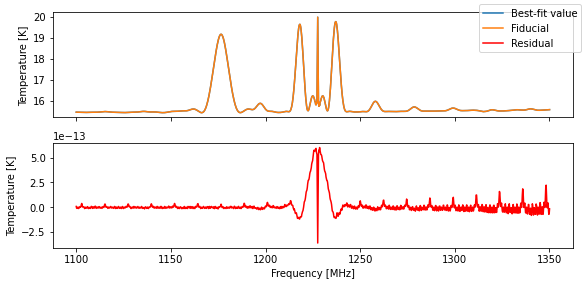

In [28]:
fig, (ax1, ax2) = plt.subplots(2,1, sharex=True, figsize=(8,4))

ax1.plot(freqs, sat3.simulation_slice, label='Best-fit value')
ax1.plot(freqs, pseudo_data_mean, label='Fiducial')
ax1.set_ylabel('Temperature [K]')

ax2.plot(freqs, sat3.simulation_slice - pseudo_data_mean, color='r', label='Residual')
ax2.set_xlabel('Frequency [MHz]')
ax2.set_ylabel('Temperature [K]')

fig.legend()
fig.tight_layout()
# plt.savefig('pseudo_test.png')